In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('../local_save_data/joined_data.csv')
print(df.head())

   truck_id       truck_name              truck_description  has_card_reader  \
0         1  Burrito Madness  An authentic taste of Mexico.                1   
1         1  Burrito Madness  An authentic taste of Mexico.                1   
2         1  Burrito Madness  An authentic taste of Mexico.                1   
3         1  Burrito Madness  An authentic taste of Mexico.                1   
4         1  Burrito Madness  An authentic taste of Mexico.                1   

   fsa_rating  transaction_id  payment_method_id  total                   at  \
0           4               1                  2  810.0  2026-02-22 09:19:00   
1           4               2                  2  700.0  2026-02-22 09:32:00   
2           4               3                  1  810.0  2026-02-22 09:44:00   
3           4               4                  1  700.0  2026-02-22 09:51:00   
4           4               5                  1  700.0  2026-02-22 09:54:00   

  payment_method  
0           card  


In [38]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']

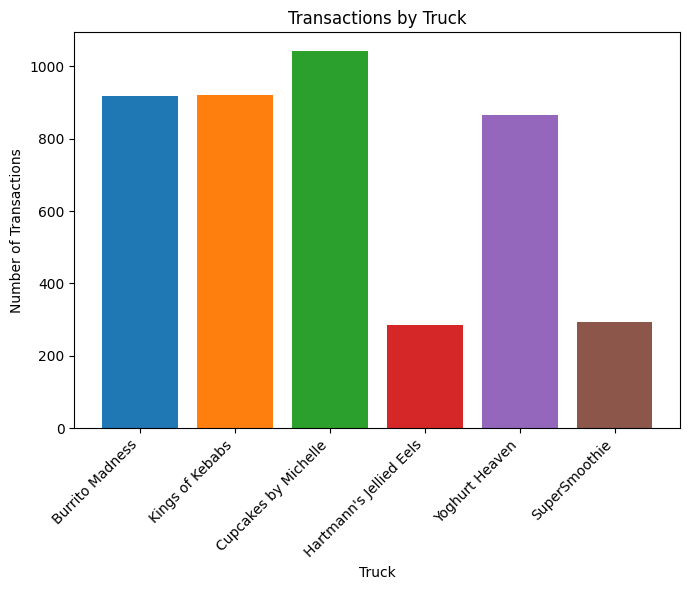

In [39]:
df['at'] = pd.to_datetime(df['at'])
counts = df.groupby('truck_id').size().reset_index(name='count')
merged = counts.merge(df[['truck_id','truck_name']].drop_duplicates(), on='truck_id', how='left')
plt.figure(figsize=(7,6))
plt.bar(merged['truck_name'], merged['count'], color=colors)
plt.xlabel('Truck') 
plt.ylabel('Number of Transactions')
plt.title('Transactions by Truck')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

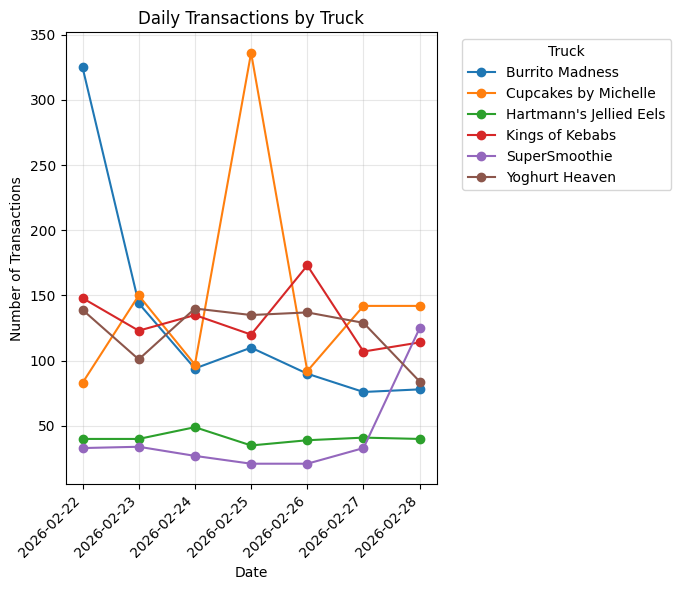

In [40]:
df['at'] = pd.to_datetime(df['at'])
df['date'] = df['at'].dt.date

daily_by_truck = df.groupby(['date', 'truck_name']).size().unstack(
    fill_value=0).sort_index()

plt.figure(figsize=(7, 6))
for truck in daily_by_truck.columns:
    plt.plot(daily_by_truck.index,
             daily_by_truck[truck], marker='o', label=truck)

plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Daily Transactions by Truck')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Truck', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

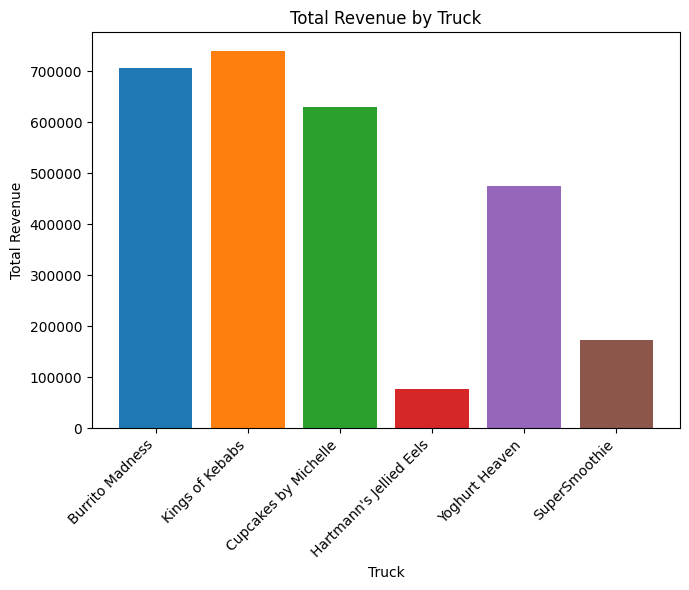

In [ ]:
# Bar chart: total revenue by truck
sum_revenue = df.groupby('truck_id')['total'].sum().reset_index()
merged_rev = sum_revenue.merge(df_trucks, on='truck_id', how='left')
plt.figure(figsize=(7,6))
plt.bar(merged_rev['truck_name'], merged_rev['total'], color=colors)
plt.xlabel('Truck')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Truck')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()